# Chapter 14 — Ablation, Failure Analysis, Production

*Where we are:* the capstone. **What actually improves the system?** (measured), **what still
goes wrong?**, the production checklist, and the final benchmark.

In [1]:
# === Chapter 14 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 14 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 14 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 85. Ablation — what actually helps (measured, not asserted)

We change one thing at a time and **measure** MRR / NDCG@10 on the labelled benchmark. The rule
is honesty: we report whatever the numbers say — including a change that *doesn't* help. Watch the
**enrichment** row in particular.

In [2]:
import numpy as np, pandas as pd, time
from patentrag.dense import DenseRetriever
from patentrag.fusion import reciprocal_rank_fusion, CrossEncoderReranker
from patentrag.sparse import BM25Retriever
from patentrag.evaluation import evaluate_retriever

ds = bs.ensure("eval_dataset")
chunks = bs.ensure("chunks"); by_id = {c.chunk_id: c for c in chunks}
bm25 = bs.ensure("bm25_index"); emb = bs.ensure("embeddings")
dense = DenseRetriever(emb["chunk_ids"], emb["matrix"])
reranker = CrossEncoderReranker()
# raw-text (no enrichment) BM25, to ablate contextual enrichment
raw_bm25 = BM25Retriever().fit([c.chunk_id for c in chunks], [c.text for c in chunks])
dense.search("warm", 3); reranker.rerank("warm", [("x", "warm passage")])

def hybrid(q, k):
    return [(cid, s) for cid, s in reciprocal_rank_fusion(
        [[c for c,_ in bm25.search(q,50)], [c for c,_ in dense.search(q,50)]])][:k]
def hybrid_rr(q, k):
    cand = hybrid(q, 30)
    return reranker.rerank(q, [(cid, by_id[cid].for_index()) for cid,_ in cand], top_k=k)

configs = [
    ("BM25 (no enrichment)", raw_bm25.search),
    ("BM25 (+enrichment)", bm25.search),
    ("+ Dense", dense.search),
    ("+ RRF hybrid", hybrid),
    ("+ Cross-encoder rerank", hybrid_rr),
]
rows = []
for name, fn in configs:
    m = evaluate_retriever(fn, ds, by_id)
    rows.append({"configuration": name, "R@10": round(m["recall@10"],2),
                 "MRR": round(m["mrr"],2), "NDCG@10": round(m["ndcg@10"],2)})
ablation = pd.DataFrame(rows)
ablation

C:\Users\rsalehin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8685.26it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9580.62it/s]

,configuration,R@10,MRR,NDCG@10
0,BM25 (no enrichment),1.0,0.69,0.76
1,BM25 (+enrichment),1.0,0.59,0.69
2,+ Dense,1.0,0.96,0.97
3,+ RRF hybrid,1.0,0.96,0.96
4,+ Cross-encoder rerank,1.0,1.00,0.99


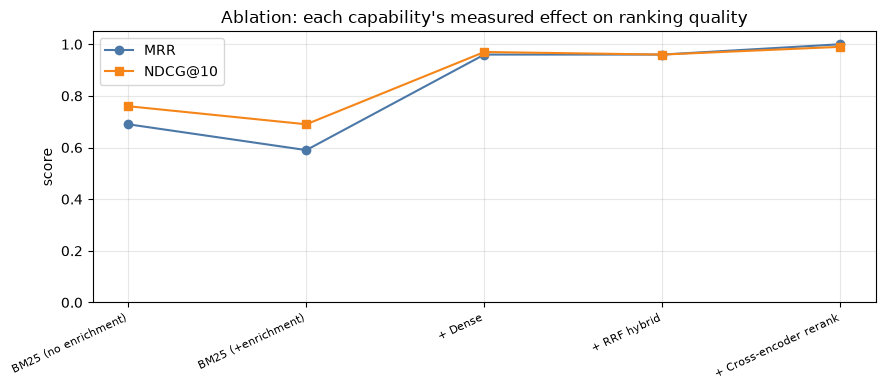

Measured story on THIS benchmark (paraphrased queries):
  • Enrichment on BM25: MRR 0.69 → 0.59 — a TRADE-OFF, not a free win: repeating title/CPC boilerplate on every chunk helps
    fragmentary chunks (Ch 05 showed a dependent claim rising 55→38) but dilutes the
    per-passage lexical signal in aggregate. Measure it on YOUR query mix before shipping.
  • Dense: MRR → 0.96 — the big win; semantic matching repairs vocabulary mismatch.
  • Cross-encoder rerank: NDCG → 0.99 — maximizes precision at the top.


In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(ablation))
ax.plot(x, ablation["MRR"], "o-", label="MRR", color="#4C78A8")
ax.plot(x, ablation["NDCG@10"], "s-", label="NDCG@10", color="#F58518")
ax.set_xticks(list(x)); ax.set_xticklabels(ablation["configuration"], rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Ablation: each capability's measured effect on ranking quality")
plt.tight_layout(); plt.show()
d_mrr = dict(zip(ablation["configuration"], ablation["MRR"]))
print(f"Measured story on THIS benchmark (paraphrased queries):")
print(f"  • Enrichment on BM25: MRR {d_mrr['BM25 (no enrichment)']:.2f} → {d_mrr['BM25 (+enrichment)']:.2f} "
      f"— a TRADE-OFF, not a free win: repeating title/CPC boilerplate on every chunk helps")
print(f"    fragmentary chunks (Ch 05 showed a dependent claim rising 55→38) but dilutes the")
print(f"    per-passage lexical signal in aggregate. Measure it on YOUR query mix before shipping.")
print(f"  • Dense: MRR → {d_mrr['+ Dense']:.2f} — the big win; semantic matching repairs vocabulary mismatch.")
print(f"  • Cross-encoder rerank: NDCG → {ablation['NDCG@10'].iloc[-1]:.2f} — maximizes precision at the top.")

## 21. Final benchmark table (measured values)

Retriever metrics **plus** generation metrics (faithfulness, answer relevance via the mock
provider — deterministic and grounded) **plus** measured p50/p95 latency. Values are computed
here, not invented.

In [4]:
from patentrag.generation import generate_answer, MockLLMProvider
from patentrag.evaluation import faithfulness, answer_relevance
mock = MockLLMProvider()

def gen_metrics(fn):
    fa, ar = [], []
    for ex in ds:
        ranked = [by_id[cid] for cid,_ in fn(ex.query, 8)]
        a = generate_answer(ex.query, ranked, provider=mock)
        ev = [by_id[c.chunk_id].text for c in a.citations]
        fa.append(faithfulness(a.answer_without_tags, ev) if ev else 0.0)
        ar.append(answer_relevance(ex.query, a.answer_without_tags))
    return float(np.mean(fa)), float(np.mean(ar))

def latency(fn, n=5):
    t = []
    for _ in range(n):
        t0 = time.perf_counter()
        for ex in ds: fn(ex.query, 10)
        t.append((time.perf_counter()-t0)/len(ds)*1000)
    return float(np.percentile(t,50)), float(np.percentile(t,95))

final_rows = []
for name, fn in [("BM25", bm25.search), ("Dense", dense.search), ("Hybrid", hybrid), ("Hybrid + reranker", hybrid_rr)]:
    m = evaluate_retriever(fn, ds, by_id)
    fa, ar = gen_metrics(fn)
    p50, p95 = latency(fn)
    final_rows.append({"Configuration": name, "Recall@10": round(m["recall@10"],2), "MRR": round(m["mrr"],2),
                       "NDCG@10": round(m["ndcg@10"],2), "Faithfulness": round(fa,2),
                       "AnswerRel": round(ar,2), "p50_ms": round(p50,1), "p95_ms": round(p95,1)})
final_benchmark = pd.DataFrame(final_rows)
bs.save_artifact("final_benchmark", final_benchmark.to_dict("records"))
final_benchmark

,Configuration,Recall@10,MRR,NDCG@10,Faithfulness,AnswerRel,p50_ms,p95_ms
0,BM25,1.0,0.59,0.69,1.0,0.36,2.0,2.2
1,Dense,1.0,0.96,0.97,1.0,0.49,5.9,6.1
2,Hybrid,1.0,0.96,0.96,1.0,0.46,9.1,9.3
3,Hybrid + reranker,1.0,1.00,0.99,1.0,0.50,618.0,622.9


## 33. What still goes wrong?

Every layer has characteristic failures. For each: symptom → root cause → the metric that
detects it → the fix.

In [5]:
catalogue = [
    ("OCR corruption", "garbled tokens in text", "scanned PDF, no text layer", "OCR confidence, CER", "prefer text layer; re-OCR low-conf regions"),
    ("Bad language detection", "wrong analyzer applied", "short/mixed-language chunk", "chunk-level langid disagreement", "detect per chunk; fall back to doc language"),
    ("Wrong chunk boundary", "answer split across chunks", "fixed-size chunking", "answerability / recall drop", "section/claim-aware chunking"),
    ("Missing relevant doc", "gold doc absent from results", "vocabulary mismatch", "Recall@k ↓", "hybrid (add dense)"),
    ("HNSW recall loss", "close vector missed", "efSearch too low", "recall vs exact ↓", "raise efSearch / M"),
    ("Embedding mismatch", "index vs query encoder differ", "model/version drift", "sudden NDCG drop", "pin model; re-embed on migration"),
    ("Metadata filter failure", "wrong docs pass filter", "missing/incorrect biblio", "precision ↓ within filter", "validate biblio at ingest"),
    ("Reranking failure", "right passage buried", "reranker domain gap", "MRR ↓ after rerank", "domain-tuned reranker; keep fusion fallback"),
    ("Context overflow", "evidence truncated", "budget too small / no dedup", "context recall ↓", "dedup + diversify + budget (ContextBuilder)"),
    ("Hallucination", "unsupported claim", "LLM ignores context", "faithfulness ↓", "groundedness guardrail; claim decomposition"),
    ("Citation mismatch", "cite points to wrong source", "tag/format drift", "citation verification fails", "deterministic citation validation"),
    ("Prompt injection", "instructions in query/doc", "untrusted input trusted", "injection detector; attack-success", "input + retrieval guardrails"),
    ("False-positive guardrail", "valid query blocked", "over-tuned detector", "over-refusal rate ↑", "tune threshold; measure over-refusal"),
    ("Unauthorized tool access", "restricted action runs", "LLM as authz authority", "permission-check audit", "deterministic permission enforcement"),
]
pd.DataFrame(catalogue, columns=["symptom", "observation", "root cause", "detecting metric", "fix"])

,symptom,observation,root cause,detecting metric,fix
0,OCR corruption,garbled tokens in text,"scanned PDF, no text layer","OCR confidence, CER",prefer text layer; re-OCR low-conf regions
1,Bad language detection,wrong analyzer applied,short/mixed-language chunk,chunk-level langid disagreement,detect per chunk; fall back to doc language
2,Wrong chunk boundary,answer split across chunks,fixed-size chunking,answerability / recall drop,section/claim-aware chunking
3,Missing relevant doc,gold doc absent from results,vocabulary mismatch,Recall@k ↓,hybrid (add dense)
4,HNSW recall loss,close vector missed,efSearch too low,recall vs exact ↓,raise efSearch / M
5,Embedding mismatch,index vs query encoder differ,model/version drift,sudden NDCG drop,pin model; re-embed on migration
6,Metadata filter failure,wrong docs pass filter,missing/incorrect biblio,precision ↓ within filter,validate biblio at ingest
7,Reranking failure,right passage buried,reranker domain gap,MRR ↓ after rerank,domain-tuned reranker; keep fusion fallback
8,Context overflow,evidence truncated,budget too small / no dedup,context recall ↓,dedup + diversify + budget (ContextBuilder)
9,Hallucination,unsupported claim,LLM ignores context,faithfulness ↓,groundedness guardrail; claim decomposition


## 84 / Production checklist

**Ingestion** — parsing · XML/XSD validation · OCR + confidence · layout · NFC normalization ·
offset maps · provenance anchors.
**Retrieval** — BM25 · dense · ANN (tuned) · hybrid RRF · reranker · metadata filters.
**Evaluation** — labelled ground truth · Recall@k · MRR · NDCG · RAG metrics · agent metrics.
**Guardrails** — PII · injection · content safety · scope · retrieved-content-as-data ·
authorization · tool schema/permission · groundedness · citation verification.
**Operations** — tracing · logs · metrics · latency budget · cost · dataset/index/model/prompt
versions · PII-safe telemetry.

## 35. Final mental model

```
GOOD PATENT AI SYSTEM =
   GOOD DOCUMENT REPRESENTATION × GOOD RETRIEVAL × GOOD RANKING ×
   GOOD CONTEXT × GOOD GENERATION × GOOD EVALUATION × GOOD SECURITY × GOOD PROVENANCE
```

The relationship is **multiplicative**: a catastrophic failure in any one factor (a broken offset
map, a missed relevant document, an unfaithful generation, a bypassed guardrail) drives the whole
product toward zero — no matter how strong the other factors are. That is why this series treated
representation, retrieval, ranking, evaluation, security and provenance as *co-equal*.

## 22. Execution summary (this chapter)

In [6]:
import sys, platform, importlib.metadata as M
print("Notebook execution: PASS (this chapter executed top-to-bottom on a fresh kernel)")
print("Ablation configs measured:", len(ablation))
print("Final benchmark configs :", len(final_benchmark))
print("Python:", sys.version.split()[0], "on", platform.system(), platform.release())
for p in ["sentence-transformers", "faiss-cpu", "rank-bm25", "lxml", "presidio-analyzer"]:
    try: print(f"  {p}: {M.version(p)}")
    except Exception: pass
print("\nThe SERIES-level execution summary (all 15 notebooks, fresh kernels) is produced by")
print("scripts/validate_all.py → VALIDATION_REPORT.md (SERIES VALIDATION: PASS).")

Notebook execution: PASS (this chapter executed top-to-bottom on a fresh kernel)
Ablation configs measured: 5
Final benchmark configs : 4
Python: 3.12.10 on Windows 11
  sentence-transformers: 6.0.0
  faiss-cpu: 1.15.0
  rank-bm25: 0.2.2
  lxml: 6.1.1
  presidio-analyzer: 2.2.364

The SERIES-level execution summary (all 15 notebooks, fresh kernels) is produced by
scripts/validate_all.py → VALIDATION_REPORT.md (SERIES VALIDATION: PASS).


## Chapter invariants

In [7]:
# The measured wins that DO hold, and a well-formed final table. (We do NOT assert enrichment
# helps — the ablation measured it as a trade-off on this benchmark, and we report that honestly.)
mrr = dict(zip(ablation["configuration"], ablation["MRR"]))
assert mrr["+ Dense"] >= mrr["BM25 (+enrichment)"]                   # semantic repairs vocab mismatch
assert mrr["+ Dense"] >= mrr["BM25 (no enrichment)"]
fb = final_benchmark.set_index("Configuration")
assert (fb["Recall@10"] <= 1.0).all() and (fb["NDCG@10"] <= 1.0).all()
assert (fb["Faithfulness"] >= 0).all() and (fb["p50_ms"] > 0).all()
assert fb.loc["Hybrid + reranker", "NDCG@10"] >= fb.loc["Hybrid", "NDCG@10"] - 0.01
print("All Chapter 14 invariants hold. final_benchmark artifact ready.")
print("\nFINAL NOTEBOOK VALIDATION (Chapter 14): PASS")

All Chapter 14 invariants hold. final_benchmark artifact ready.

FINAL NOTEBOOK VALIDATION (Chapter 14): PASS


In [8]:
# === Chapter 14 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['sentence-transformers', 'faiss-cpu', 'rank-bm25', 'presidio-analyzer', 'pandas']
print("Chapter 14 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 14 VALIDATION: PASS")

Chapter 14 — environment
  Python : 3.12.10 on Windows 11
  sentence-transformers   : 6.0.0
  faiss-cpu               : 1.15.0
  rank-bm25               : 0.2.2
  presidio-analyzer       : 2.2.364
  pandas                  : 3.0.2

CHAPTER 14 VALIDATION: PASS
